## 1. Chargement des données nettoyées

**Objectif :**
Importer le dataset prétraité issu de l'étape précédente (`cleaned_loan.csv`) pour lui appliquer des transformations avancées nécessaires au Deep Learning.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Chargement du fichier nettoyé
df = pd.read_csv('../data/processed/cleaned_loan.csv')

print("Dimensions du dataset :", df.shape)
df.head()

Dimensions du dataset : (614, 15)


,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Gender_Male,Married_Yes,Dependents_1,Dependents_2,Dependents_3+,Education_Not Graduate,Self_Employed_Yes,Property_Area_Semiurban,Property_Area_Urban
0,5849,0.0,128.0,360.0,1.0,1,True,False,False,False,False,False,False,False,True
1,4583,1508.0,128.0,360.0,1.0,0,True,True,True,False,False,False,False,False,False
2,3000,0.0,66.0,360.0,1.0,1,True,True,False,False,False,False,True,False,True
3,2583,2358.0,120.0,360.0,1.0,1,True,True,False,False,False,True,False,False,True
4,6000,0.0,141.0,360.0,1.0,1,True,False,False,False,False,False,False,False,True


## Étape 2 : Feature Engineering (Création de ratios financiers)

Création de nouvelles fonctionnalités (Feature Engineering)

**Objectif :**
Combiner des variables existantes pour créer des indicateurs financiers plus représentatifs de la solvabilité du demandeur.

**Variables créées :**
- `Total_Income` : Somme des revenus (`ApplicantIncome` + `CoapplicantIncome`).
- `Income_to_Loan_Ratio` : Ratio Revenu Total / Montant du prêt.
- `EMI` : Mensualité estimée (`LoanAmount` / `Loan_Amount_Term`).

In [2]:
# 1. Revenu total du foyer
df['Total_Income'] = df['ApplicantIncome'] + df['CoapplicantIncome']

# 2. Ratio Revenu / Montant du prêt
df['Income_to_Loan_Ratio'] = df['Total_Income'] / (df['LoanAmount'] + 1e-5)

# 3. Mensualité estimée (EMI)
df['EMI'] = df['LoanAmount'] / (df['Loan_Amount_Term'] + 1e-5)

df[['Total_Income', 'Income_to_Loan_Ratio', 'EMI']].head()

,Total_Income,Income_to_Loan_Ratio,EMI
0,5849.0,45.695309,0.355556
1,6091.0,47.585934,0.355556
2,3000.0,45.454539,0.183333
3,4941.0,41.174997,0.333333
4,6000.0,42.553188,0.391667


## Étape 3 : Correction de l'asymétrie des distributions (Log Transformation)

**Objectif :**
Réduire l'impact des grandes valeurs extrêmes (outliers) sur des variables financières très étalées (`Total_Income`, `LoanAmount`) en appliquant la transformation logarithmique `np.log1p()`. Cela aide la convergence des réseaux de neurones.

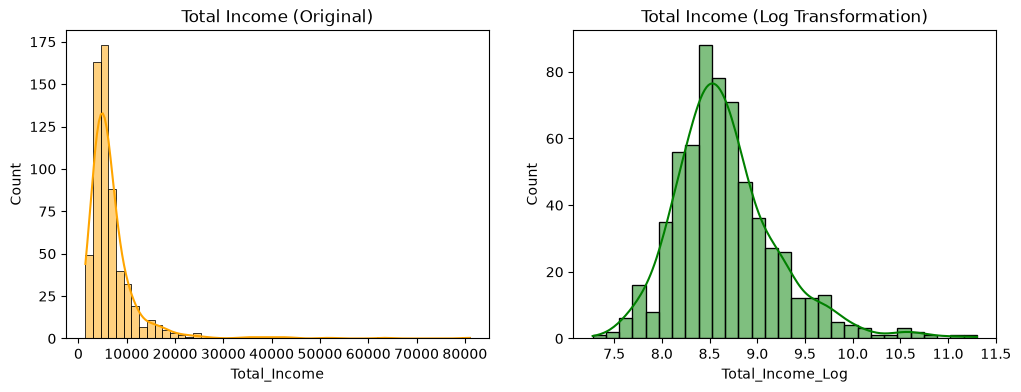

In [3]:
# Transformation log
df['Total_Income_Log'] = np.log1p(df['Total_Income'])
df['LoanAmount_Log'] = np.log1p(df['LoanAmount'])

# Visualisation Avant / Après
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df['Total_Income'], kde=True, ax=axes[0], color='orange').set_title('Total Income (Original)')
sns.histplot(df['Total_Income_Log'], kde=True, ax=axes[1], color='green').set_title('Total Income (Log Transformation)')
plt.show()

## Étape 4 : Normalisation (StandardScaler)

**Objectif :**
Mettre à l'échelle toutes les variables numériques pour qu'elles aient une moyenne de 0 et un écart-type de 1. C'est une condition indispensable pour l'entraînement d'un réseau de neurones (Deep Learning).

In [4]:
from sklearn.preprocessing import StandardScaler

# Séparation des features (X) et de la cible (y)
X = df.drop(columns=['Loan_Status'])
y = df['Loan_Status']

# Standardisation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Reconstitution du DataFrame
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)
X_scaled_df.head()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Gender_Male,Married_Yes,Dependents_1,Dependents_2,Dependents_3+,Education_Not Graduate,Self_Employed_Yes,Property_Area_Semiurban,Property_Area_Urban,Total_Income,Income_to_Loan_Ratio,EMI,Total_Income_Log,LoanAmount_Log
0,0.072991,-0.554487,-0.211241,0.273231,0.411733,0.472343,-1.372089,-0.446339,-0.443713,-0.300975,-0.528362,-0.392601,-0.782016,1.428147,-0.182184,-0.145811,-0.231305,0.008426,-0.012803
1,-0.134412,-0.038732,-0.211241,0.273231,0.411733,0.472343,0.728816,2.240448,-0.443713,-0.300975,-0.528362,-0.392601,-0.782016,-0.700208,-0.144684,-0.095634,-0.231305,0.082860,-0.012803
2,-0.393747,-0.554487,-0.948996,0.273231,0.411733,0.472343,0.728816,-0.446339,-0.443713,-0.300975,-0.528362,2.547117,-0.782016,1.428147,-0.623656,-0.152201,-0.568521,-1.217299,-1.348663
3,-0.462062,0.251980,-0.306435,0.273231,0.411733,0.472343,0.728816,-0.446339,-0.443713,-0.300975,1.892641,-0.392601,-0.782016,1.428147,-0.322885,-0.265781,-0.274817,-0.301306,-0.143351
4,0.097728,-0.554487,-0.056551,0.273231,0.411733,0.472343,-1.372089,-0.446339,-0.443713,-0.300975,-0.528362,-0.392601,-0.782016,1.428147,-0.158785,-0.229204,-0.160598,0.055223,0.182981


## Étape 5 : Sauvegarde des données transformées

**Objectif :**
Sauvegarder les données transformées et le scaler dans le dossier `data/processed/` et `models/` afin d'alimenter directement le notebook de Deep Learning (`deep_learning.ipynb`).

In [5]:
import joblib

# Concatenation X_scaled et y
df_transformed = X_scaled_df.copy()
df_transformed['Loan_Status'] = y.values

# Sauvegarde du CSV transformé
df_transformed.to_csv('../data/processed/transformed_loan.csv', index=False)

# Sauvegarde du Scaler pour app.py
joblib.dump(scaler, '../models/preprocessor.pkl')

print(" Données transformées sauvegardées dans 'data/processed/transformed_loan.csv'")
print(" Scaler sauvegardé dans 'models/preprocessor.pkl'")

 Données transformées sauvegardées dans 'data/processed/transformed_loan.csv'
 Scaler sauvegardé dans 'models/preprocessor.pkl'
